# Decision Tree on Digits + Metrics



In [40]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load digits data (X, y)

In [41]:
df=load_digits()
X=df.data
y=df.target

Split into train/test (80/20, stratified, fixed random_state)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1437, 64) (1437,)
Test : (360, 64) (360,)


Train a DecisionTreeClassifier (set max_depth=10, fixed random_state).

In [44]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

On the test set, compute and print:

    	•	accuracy
    	•	macro precision
    	•	macro recall
    	•	macro F1-score

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [46]:
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.8083333333333333


In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1-score:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.8083333333333333
Precision: 0.8080060754518961
Recall: 0.8078142428142427
F1-score: 0.8067653606902354


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92        36
           1       0.75      0.67      0.71        36
           2       0.79      0.86      0.82        35
           3       0.77      0.81      0.79        37
           4       0.91      0.83      0.87        36
           5       0.85      0.92      0.88        37
           6       0.91      0.89      0.90        36
           7       0.72      0.78      0.75        36
           8       0.75      0.69      0.72        35
           9       0.74      0.69      0.71        36

    accuracy                           0.81       360
   macro avg       0.81      0.81      0.81       360
weighted avg       0.81      0.81      0.81       360



confusion matrix visualization

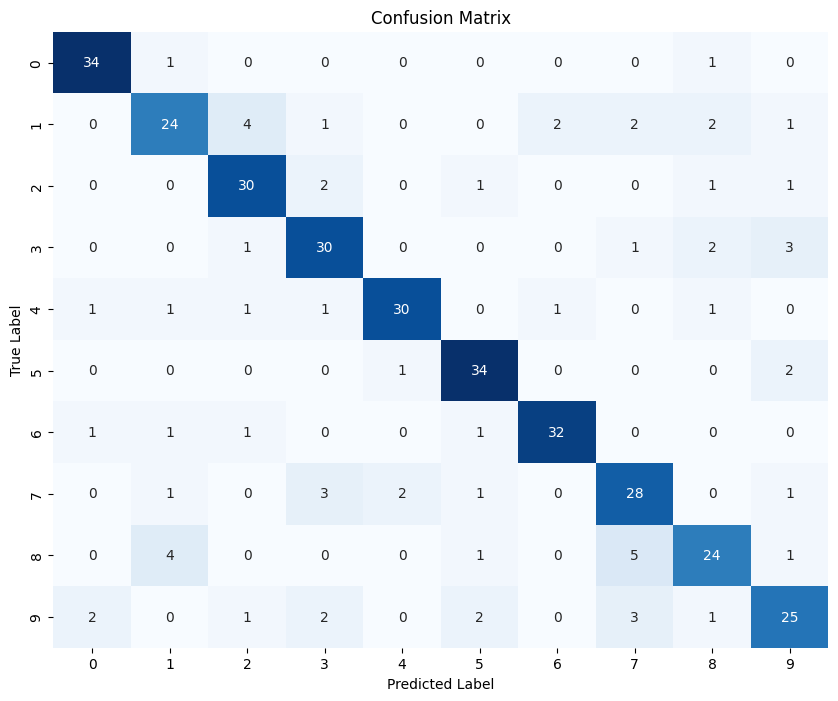

In [49]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

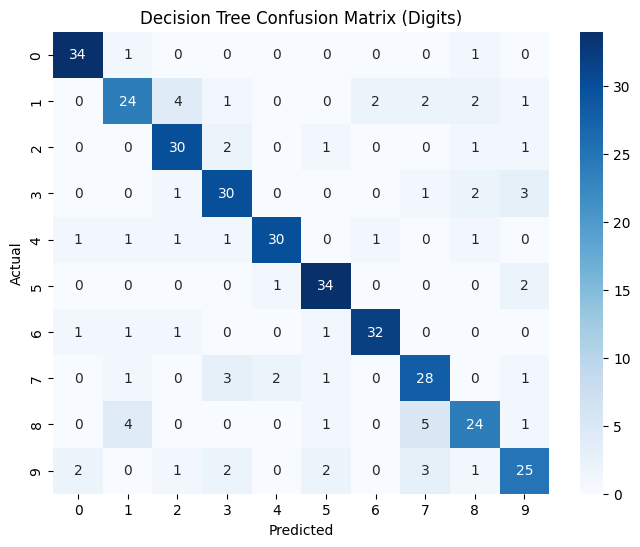

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix (Digits)")
plt.show()

#AdaBoost (stumps) vs Decision Tree

**Using the same train/test split:**


Train an AdaBoostClassifier where the base learner is a decision stump (DecisionTreeClassifier(max_depth=1)).

In [51]:
from sklearn.ensemble import AdaBoostClassifier

In [52]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

Evaluate AdaBoost test accuracy.

In [53]:
y_pred_ada = ada.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_ada))

Accuracy: 0.8305555555555556


Print both accuracies in one line:

    	•	Decision Tree accuracy
    	•	AdaBoost accuracy

In [54]:
dt_acc = acc
ada_acc = accuracy_score(y_test, y_pred_ada)
print(f"Decision Tree Accuracy: {dt_acc:.4f} | AdaBoost Accuracy: {ada_acc:.4f}")

Decision Tree Accuracy: 0.8083 | AdaBoost Accuracy: 0.8306


# Cross-validation

5-Fold CV score

**Using digits dataset again:**



Create a 5-fold cross-validation object that keeps class balance (stratified)

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Compute cross-validation accuracy for AdaBoost using cross_val_score

In [56]:
scores = cross_val_score(ada, X, y, cv=cv, scoring='accuracy')

 Print:

    •   all 5 scores
    •   mean score
    •   standard deviation

In [57]:
print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

CV Scores: [0.83611111 0.78611111 0.7994429  0.82729805 0.79665738]
Mean Accuracy: 0.8091241101826061
Standard Deviation: 0.019169421744118353


In [58]:
#F1 score
cv_scores_f1 = cross_val_score(ada, X, y, cv=cv, scoring="f1_macro")
print("CV F1_macro scores:", cv_scores_f1)
print("Mean CV F1_macro  :", cv_scores_f1.mean())
print("Std CV F1_macro   :", cv_scores_f1.std())

CV F1_macro scores: [0.83860286 0.78191557 0.79989948 0.82960372 0.79687009]
Mean CV F1_macro  : 0.8093783461910291
Std CV F1_macro   : 0.02127744025670795


# Clustering + Evaluation

KMeans + Silhouette


In [59]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**Create a dataset using make_blobs(n_samples=400, centers=4, random_state=42).**

In [60]:
X,y = make_blobs(n_samples=400, centers=4, random_state=42)

Scale the data.

In [61]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Run KMeans(K=4)

In [62]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

Compute SSE and visualize the optimal K value

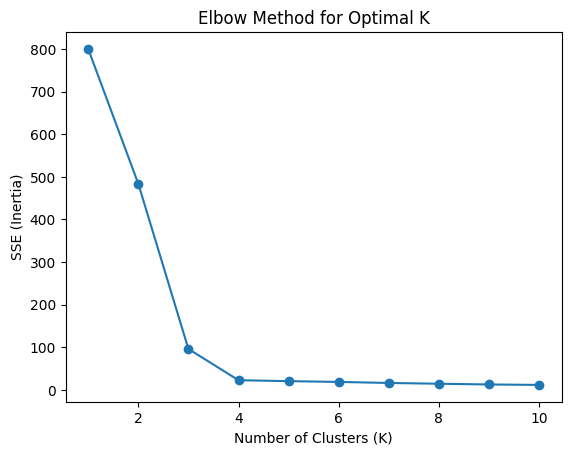

In [63]:
sse = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)   # SSE (inertia)
plt.figure()
plt.plot(K, sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.show()

Plot the clustered scatter plot (color by cluster label).

In [63]:
plt.figure()
labels = kmeans.labels_
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)

# Plot centroids (optional but better)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200)

plt.title('KMeans Clustering (K=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

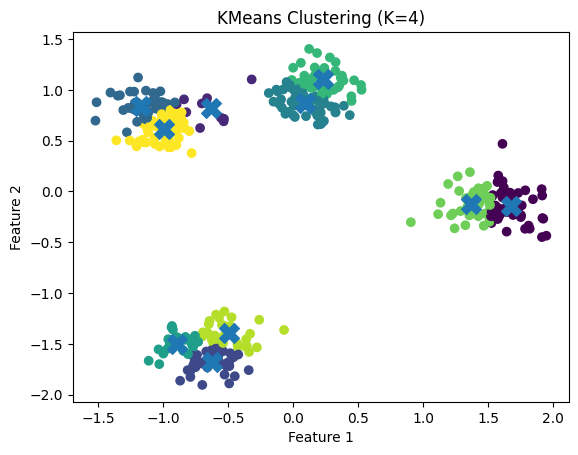

In [64]:
#4.  Plot the clustered scatter plot (color by cluster label).
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)

# Plot centroids (optional but better)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200)

plt.title('KMeans Clustering (K=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()